# Advanced Outlier Detection Engine
 **Objective:** Identify anomalous transaction amounts using the 3-Sigma (Z-Score) rule per user.
 
 **Compliance:** Logs anomalies for further review in accordance with FinTech security standards.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import logging
import snowflake.connector
from snowflake.connector.pandas_tools import write_pandas

# Professional Logging Setup
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

# Integration with Vault & Security
sys.path.append('..') 
from security.vault_client import VaultClient

# Directory Setup for Results
os.makedirs('../results/eda_plots', exist_ok=True)

# 1. Secure Connection via Vault
try:
    vault = VaultClient()
    secrets = vault.get_snowflake_config()
    conn = snowflake.connector.connect(
        account=secrets['account'],
        user=secrets['user'],
        password=secrets['password'],
        warehouse=secrets['warehouse'],
        database=secrets['database'],
        schema='SILVER'
    )
    logger.info("Secure connection to Snowflake established.")
except Exception as e:
    logger.error(f"Connection failed: {e}")
    sys.exit(1)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')

2026-04-17 15:57:17,818 - INFO - Vault Connection Established: http://localhost:8200
2026-04-17 15:57:17,864 - INFO - Vault Connection Established: http://localhost:8200
2026-04-17 15:57:17,897 - INFO - Snowflake Connector for Python Version: 4.4.0, Python Version: 3.12.10, Platform: Windows-11-10.0.26200-SP0
2026-04-17 15:57:17,900 - INFO - Connecting to GLOBAL Snowflake domain
2026-04-17 15:57:19,895 - INFO - Secure connection to Snowflake established.


## 1. Data Ingestion & Transformation

In [2]:
# Optimized Query using Snowflake native functions
query = """
    SELECT 
        transaction_id, user_id, amount, timestamp, location, is_fraud
    FROM FRAUD_DB.SILVER.silver_enriched_transactions
    WHERE timestamp >= DATEADD('day', -30, CURRENT_DATE())
"""

logger.info("Fetching 30-day transaction window...")
cursor = conn.cursor()
cursor.execute(query)
df = cursor.fetch_pandas_all()

if df.empty:
    logger.warning("No data found in the specified window.")
else:
    # Normalize column names and types
    df.columns = [col.lower() for col in df.columns]
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['amount'] = df['amount'].astype(float)
    logger.info(f"Loaded {len(df):,} transactions for analysis.")

2026-04-17 15:57:33,913 - INFO - Fetching 30-day transaction window...
2026-04-17 15:57:34,180 - INFO - Loaded 1,000 transactions for analysis.


## 2. Per-User Anomaly Detection (Z-Score)

In [3]:
# Log transform to handle skewed financial data
df['amount_log'] = np.log1p(df['amount'])

logger.info("Calculating per-user statistical boundaries...")

# Group-based Z-score calculation
user_group = df.groupby('user_id')['amount_log']
df['user_mean'] = user_group.transform('mean')
df['user_std'] = user_group.transform('std')

# Calculate Z-score with handling for single-transaction users (std=0)
df['z_score'] = np.where(
    df['user_std'] > 0, 
    (df['amount_log'] - df['user_mean']) / df['user_std'], 
    0
)

# Apply 3-Sigma Rule
df['is_outlier'] = np.abs(df['z_score']) > 3
outliers = df[df['is_outlier'] == True].copy().reset_index(drop=True)

logger.info(f"Anomaly detection complete. Found {len(outliers)} outliers.")

2026-04-17 15:57:43,269 - INFO - Calculating per-user statistical boundaries...
2026-04-17 15:57:43,304 - INFO - Anomaly detection complete. Found 0 outliers.


## 3. Visualizing Anomalies

2026-04-17 15:57:53,298 - INFO - Skipping anomaly-specific plots: No outliers found.


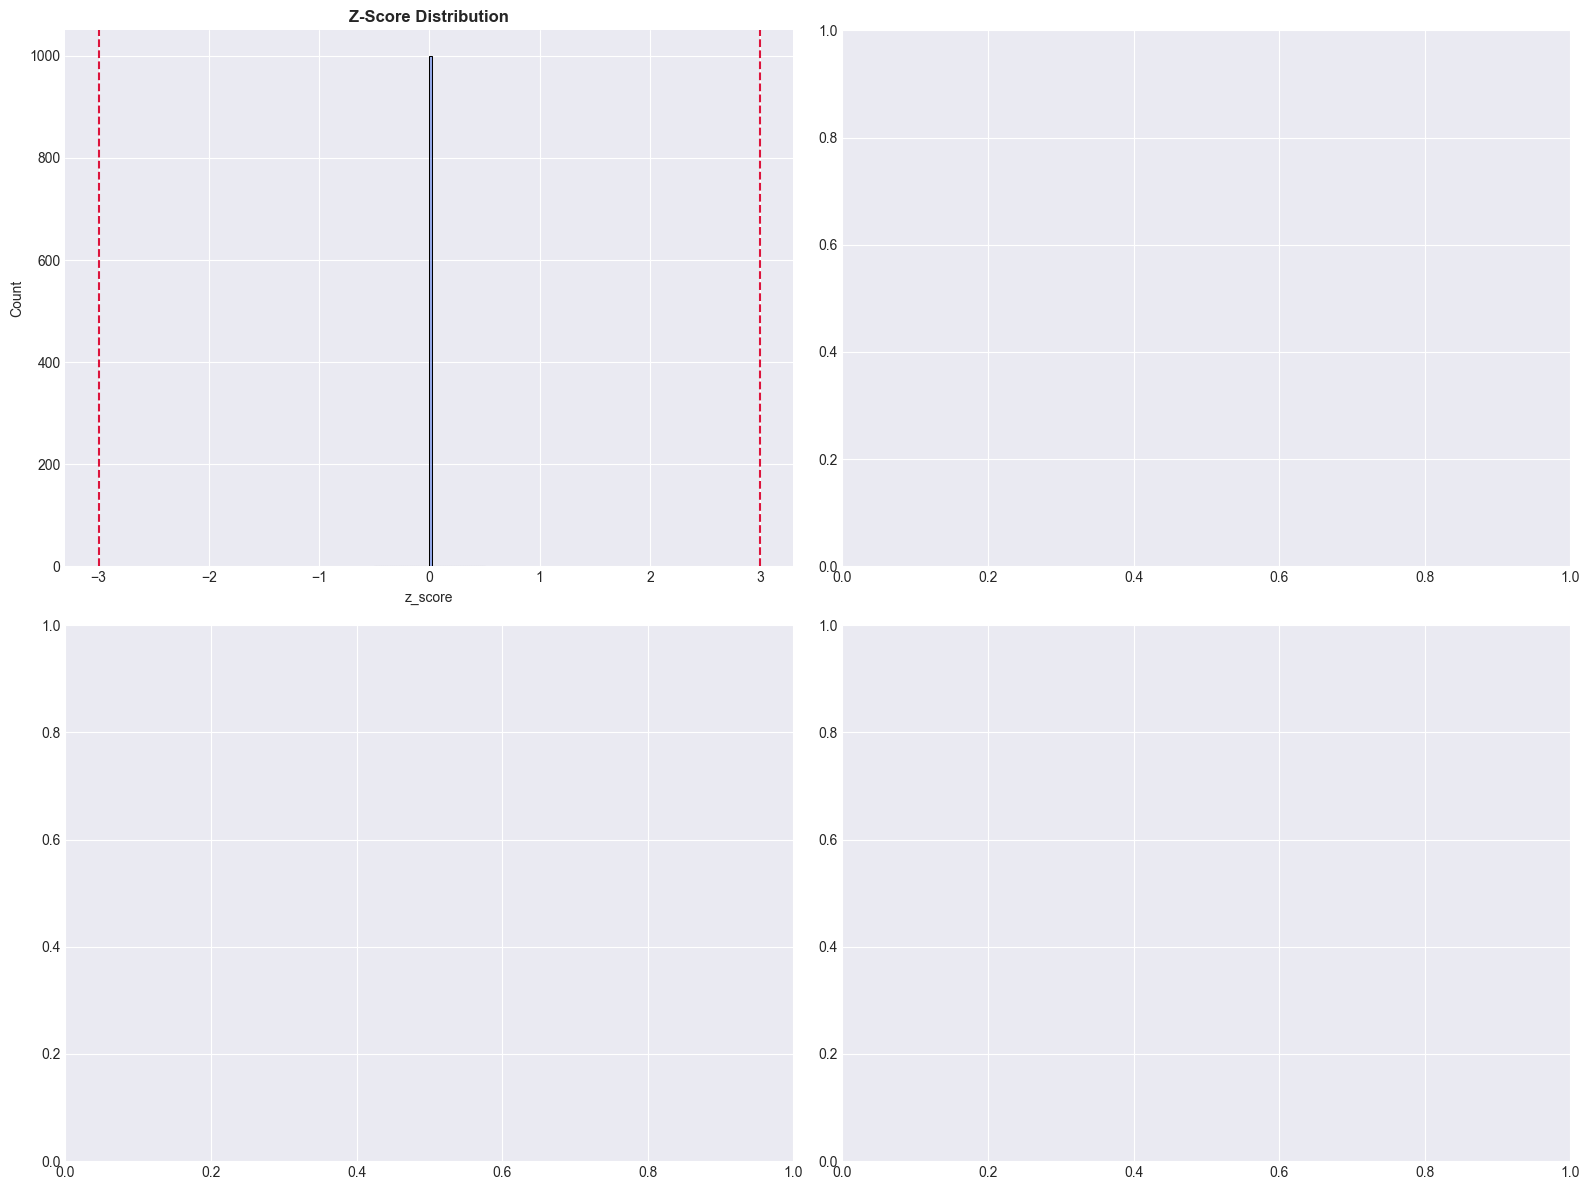

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Distribution
sns.histplot(df['z_score'], bins=50, kde=True, ax=axes[0,0], color='royalblue')
axes[0,0].axvline(x=3, color='crimson', linestyle='--')
axes[0,0].axvline(x=-3, color='crimson', linestyle='--')
axes[0,0].set_title('Z-Score Distribution', fontweight='bold')

# Plot 2: Outlier vs Fraud Status
if not outliers.empty:
    fraud_counts = outliers['is_fraud'].value_counts().rename({True: 'Fraud', False: 'Normal'})
    fraud_counts.plot(kind='bar', ax=axes[0,1], color=['orange', 'red'])
    axes[0,1].set_title('Outliers by Fraud Label', fontweight='bold')
    
    # Plot 3: Boxplot comparison
    sns.boxplot(data=df, x='is_outlier', y='amount', ax=axes[1,0])
    axes[1,0].set_yscale('log')
    axes[1,0].set_title('Amount: Outlier vs Normal (Log Scale)', fontweight='bold')

    # Plot 4: Top Hotspots
    top_locs = outliers['location'].value_counts().head(10)
    sns.barplot(x=top_locs.values, y=top_locs.index, ax=axes[1,1], palette='Reds_r')
    axes[1,1].set_title('Top 10 Anomaly Locations', fontweight='bold')
else:
    logger.info("Skipping anomaly-specific plots: No outliers found.")

plt.tight_layout()
plt.savefig('../results/eda_plots/outlier_analysis_final.png', dpi=300)
plt.show()

## 4. Synchronizing to Snowflake (Bulk Load)

In [5]:
logger.info("Syncing outlier logs to Snowflake...")

# Prepare table
cursor.execute("""
    CREATE OR REPLACE TABLE silver_outlier_log (
        transaction_id STRING,
        user_id STRING,
        amount NUMBER(15,2),
        z_score NUMBER(10,4),
        detection_timestamp TIMESTAMP_NTZ DEFAULT CURRENT_TIMESTAMP(),
        is_reviewed BOOLEAN DEFAULT FALSE
    )
""")

if not outliers.empty:
    # Prepare data for upload
    upload_df = outliers[['transaction_id', 'user_id', 'amount', 'z_score']].copy()
    upload_df.columns = [col.upper() for col in upload_df.columns]
    
    # Professional Bulk Ingestion
    success, nchunks, nrows, _ = write_pandas(conn, upload_df, 'SILVER_OUTLIER_LOG')
    logger.info(f"Successfully synchronized {nrows} anomalies to Snowflake.")
else:
    logger.info("No anomalies to synchronize.")

2026-04-17 15:58:03,914 - INFO - Syncing outlier logs to Snowflake...
2026-04-17 15:58:04,205 - INFO - No anomalies to synchronize.


## 5. Operational Alerting

In [6]:
def trigger_alert(threshold=5):
    if len(outliers) > threshold:
        print("\n" + "!"*50)
        print(f"CRITICAL ALERT: {len(outliers)} Anomalies Detected")
        print("!"*50)
        return True
    return False

trigger_alert()

False